# ADS-B RFSoC I/Q physical-layer transmitter identification with K-fold validation

This is the same broad experiment as the earlier ADS-B I/Q notebooks, but adapted to the `record.npy` capture produced by the board-side signal-detection work. The file is an appended stream of timestamp and I/Q arrays. Each I/Q array is already one preamble-aligned 1,200-sample ADS-B record, so I am rebuilding those short records rather than treating the file as one ordinary NumPy array.

I am decoding each record in the same way as `pynq/signal_detection/src/save_queue.py`: take the magnitude, average every five samples into one half-symbol, discard the 16-half-symbol preamble, compare the two halves of each PPM bit, pack the 112 bits, and validate/decode the message with pyModeS. The decoded ICAO address is only used as the supervised class label.

The working idea is still to see whether a model can learn repeatable physical-layer differences between aircraft/transponder emissions directly from raw I/Q. I am keeping the decoded message, ICAO address, type code, and timestamp out of the model inputs, because otherwise the model could learn message contents or capture order instead of signal-level behaviour.

The basic flow is:

1. read the appended timestamp/IQ pairs from `record.npy`,
2. keep each 1,200-sample ADS-B record as one short segment,
3. demodulate and CRC-check each record with the signal-detection settings,
4. use the pyModeS ICAO value as the supervised class label,
5. filter aircraft with too few records for K-fold validation,
6. normalise each record,
7. train the same compact 1D CNN with stratified K-fold validation.


In [ ]:
# Optional setup
# Only need this if the environment is missing a package.
# pyModeS 2.x is pinned because it matches the API used in pynq/signal_detection.
%pip install numpy pandas scikit-learn matplotlib torch "pyModeS<3"


In [ ]:
# Configuration
from pathlib import Path

CONFIG = {
    # record.npy sits outside the repository in the current project workspace.
    "capture_path": Path("../../../data/record.npy"),

    # signal_detection uses 2 MHz ADS-B timing with a 5x sample-rate multiplier.
    "sample_rate_hz": 10e6,
    "samples_per_half_symbol": 5,
    "preamble_half_symbols": 16,
    "message_bits": 112,
    "window_len": 1200,

    "normalise_per_record": True,
    "demean": True,

    # ICAO is not used as an input feature. It is only the training label.
    "label_column": "icao",
    "required_df": 17,
    "valid_crc_only": True,
    "min_records_per_class": 5,
    "max_records_per_class": None,    # set to an int to balance/debug later

    # K-fold settings.
    "n_splits": 5,
    "random_seed": 42,

    # Model settings.
    "num_filters_1": 32,
    "num_filters_2": 64,
    "num_filters_3": 96,
    "kernel_size": 7,
    "dropout_conv": 0.15,
    "dropout_fc": 0.35,
    "fc_units": 128,

    # Training settings.
    "batch_size": 64,
    "epochs": 15,
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "patience": 4,

    # Outputs.
    "artifact_dir": Path("./adsb_iq_rfsoc_outputs"),
}

CONFIG["artifact_dir"].mkdir(parents=True, exist_ok=True)
CONFIG


{'capture_path': PosixPath('../../../data/record.npy'),
 'sample_rate_hz': 10000000.0,
 'samples_per_half_symbol': 5,
 'preamble_half_symbols': 16,
 'message_bits': 112,
 'window_len': 1200,
 'normalise_per_record': True,
 'demean': True,
 'label_column': 'icao',
 'required_df': 17,
 'valid_crc_only': True,
 'min_records_per_class': 5,
 'max_records_per_class': None,
 'n_splits': 5,
 'random_seed': 42,
 'num_filters_1': 32,
 'num_filters_2': 64,
 'num_filters_3': 96,
 'kernel_size': 7,
 'dropout_conv': 0.15,
 'dropout_fc': 0.35,
 'fc_units': 128,
 'batch_size': 64,
 'epochs': 15,
 'learning_rate': 0.001,
 'weight_decay': 0.0001,
 'patience': 4,
 'artifact_dir': PosixPath('adsb_iq_rfsoc_outputs')}

## Data setup

`record.npy` is not a single array. The capture writer opens the same file in append mode and calls `np.save` twice per detection: first for the timestamp and then for the 1,200 complex I/Q samples. I need to step through the file until EOF and reconstruct those pairs.

The timestamp was saved as a Python object, so loading that one value requires `allow_pickle=True`. I am limiting that to the timestamp entry and loading every I/Q array with pickling disabled. This should only be used with a capture produced by our own writer.

At 10 MSPS, 1,200 samples cover the 8 µs preamble and 112 µs DF17 message. The writer has already used its preamble detector to choose these boundaries, so each stored array is the short segment used by the classifier.


In [ ]:
# Imports and reproducibility
import json
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyModeS as pms

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.preprocessing import LabelEncoder

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

if not hasattr(pms, "crc") or not hasattr(pms, "adsb"):
    raise ImportError(
        "This notebook follows the pyModeS 2.x API used by signal_detection. "
        "Run the optional setup cell to install pyModeS<3."
    )

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)


def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(CONFIG["random_seed"])


Using device: cpu


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# Load the appended NumPy records

def resolve_capture_path(path: Path) -> Path:
    candidates = [
        Path(path),
        Path("data/record.npy"),
        Path("../data/record.npy"),
        Path("../../data/record.npy"),
        Path("../../../data/record.npy"),
    ]

    for candidate in candidates:
        if candidate.is_file():
            return candidate.resolve()

    checked = "\n".join(str(candidate.resolve()) for candidate in candidates)
    raise FileNotFoundError(f"Could not find record.npy. Checked:\n{checked}")


def load_appended_npy_capture(path: Path) -> pd.DataFrame:
    path = resolve_capture_path(path)
    rows = []
    file_size = path.stat().st_size

    with path.open("rb") as stream:
        record_index = 0

        while stream.tell() < file_size:
            pair_offset = stream.tell()

            try:
                # Only the timestamp entry contains a pickled Python object.
                timestamp_array = np.load(stream, allow_pickle=True)
                iq = np.load(stream, allow_pickle=False)
            except (EOFError, OSError, ValueError) as exc:
                raise ValueError(
                    f"Could not read timestamp/IQ pair {record_index} "
                    f"at byte offset {pair_offset}"
                ) from exc

            timestamp = timestamp_array.item() if timestamp_array.shape == () else timestamp_array.tolist()
            iq = np.asarray(iq)

            if iq.ndim != 1 or not np.iscomplexobj(iq):
                raise ValueError(
                    f"Record {record_index} is not a one-dimensional complex I/Q array: "
                    f"shape={iq.shape}, dtype={iq.dtype}"
                )

            rows.append({
                "record_index": record_index,
                "timestamp": timestamp,
                "sample_count": len(iq),
                "iq_dtype": str(iq.dtype),
                "iq": iq.astype(np.complex64, copy=False),
            })
            record_index += 1

    return pd.DataFrame(rows)


capture_records = load_appended_npy_capture(CONFIG["capture_path"])

print("Loaded records:", capture_records.shape)
print("Sample counts:", capture_records["sample_count"].value_counts().sort_index().to_dict())
print("I/Q dtypes:", capture_records["iq_dtype"].value_counts().to_dict())
display(capture_records.drop(columns="iq").head())


Loaded records: (255, 5)
Sample counts: {1200: 255}
I/Q dtypes: {'complex64': 255}


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,record_index,timestamp,sample_count,iq_dtype
0,0,2026-08-24 23:53:41.914383,1200,complex64
1,1,2026-08-24 23:57:27.505934,1200,complex64
2,2,2026-08-24 23:57:28.400218,1200,complex64
3,3,2026-08-24 23:57:29.305662,1200,complex64
4,4,2026-08-24 23:58:30.883164,1200,complex64


In [ ]:
# Demodulate and decode each stored ADS-B segment

def demodulate_adsb_record(iq: np.ndarray, config=CONFIG):
    samples_per_half = config["samples_per_half_symbol"]
    preamble_halves = config["preamble_half_symbols"]
    message_bits = config["message_bits"]
    required_samples = samples_per_half * (preamble_halves + 2 * message_bits)

    iq = np.asarray(iq).reshape(-1)
    if len(iq) != required_samples:
        raise ValueError(
            f"Expected {required_samples} samples for one ADS-B record, got {len(iq)}"
        )

    # This is the demodulation path used in signal_detection/src/save_queue.py.
    magnitude = np.abs(iq)
    half_symbols = magnitude.reshape(-1, samples_per_half).mean(axis=1)
    payload = half_symbols[preamble_halves:]
    payload_bits = payload[0::2] > payload[1::2]
    message = np.packbits(payload_bits).tobytes().hex().upper()
    return message, payload_bits


def decode_capture_records(capture_records: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for row in capture_records.itertuples(index=False):
        decoded = {
            "record_index": row.record_index,
            "message": None,
            "crc": np.nan,
            "df": np.nan,
            "icao": None,
            "type_code": np.nan,
            "decode_ok": False,
            "decode_error": None,
        }

        try:
            message, _ = demodulate_adsb_record(row.iq)
            decoded["message"] = message
            decoded["crc"] = int(pms.crc(message))

            if decoded["crc"] != 0:
                decoded["decode_error"] = "CRC"
            else:
                decoded["df"] = int(pms.adsb.df(message))
                decoded["icao"] = pms.adsb.icao(message)
                decoded["type_code"] = int(pms.adsb.typecode(message))
                decoded["decode_ok"] = True
        except Exception as exc:
            decoded["decode_error"] = f"{type(exc).__name__}: {exc}"

        rows.append(decoded)

    return pd.DataFrame(rows)


decoded_records = decode_capture_records(capture_records)
records = capture_records.merge(decoded_records, on="record_index", how="left")

print("CRC-valid decoded records:", int(records["decode_ok"].sum()), "/", len(records))
display(records.drop(columns="iq").head())


CRC-valid decoded records: 255 / 255


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,record_index,timestamp,sample_count,iq_dtype,message,crc,df,icao,type_code,decode_ok,decode_error
0,0,2026-08-24 23:53:41.914383,1200,complex64,8D7C68D49914668A983011A59EE5,0,17,7C68D4,19,True,None
1,1,2026-08-24 23:57:27.505934,1200,complex64,8D7C78AC580BE5217AF76323CD1D,0,17,7C78AC,11,True,None
2,2,2026-08-24 23:57:28.400218,1200,complex64,8D7C78AC990C768BC8381099551C,0,17,7C78AC,19,True,None
3,3,2026-08-24 23:57:29.305662,1200,complex64,8D7C78ACEA0138E6873C0854A302,0,17,7C78AC,29,True,None
4,4,2026-08-24 23:58:30.883164,1200,complex64,8F7C78AC5807D51CF2F4BAC9A2E1,0,17,7C78AC,11,True,None


Capture start: 2026-08-24 23:53:41.914383
Capture end:   2026-08-25 08:18:21.000327


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,records
df,
17,255


,records
type_code,
4,13
11,106
19,95
28,8
29,22
31,11


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,records
icao,
7C4758,29
7C7770,28
7C1CE4,27
7C1C49,26
7C77F6,25
7C6DDD,20
7C4A55,19
7C3AA6,18
7C03F1,17


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


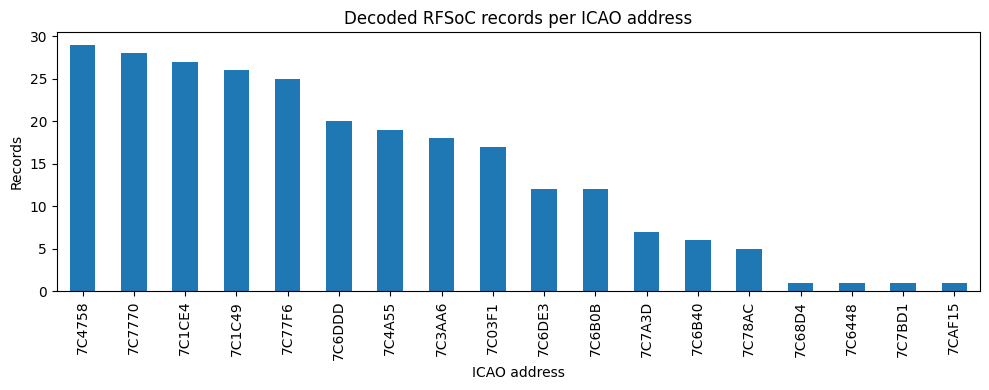

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# Quick data check
print("Capture start:", records["timestamp"].min())
print("Capture end:  ", records["timestamp"].max())

display(records["df"].value_counts(dropna=False).rename("records").to_frame())
display(records["type_code"].value_counts(dropna=False).sort_index().rename("records").to_frame())

class_counts_all = records.loc[records["decode_ok"], CONFIG["label_column"]].value_counts()
display(class_counts_all.rename("records").to_frame())

plt.figure(figsize=(10, 4))
class_counts_all.sort_values(ascending=False).plot(kind="bar")
plt.title("Decoded RFSoC records per ICAO address")
plt.xlabel("ICAO address")
plt.ylabel("Records")
plt.tight_layout()
plt.show()


In [ ]:
# I/Q preparation after decoding and class filtering

def crop_or_pad_iq(iq: np.ndarray, window_len: int) -> np.ndarray:
    iq = np.asarray(iq, dtype=np.complex64).reshape(-1)

    if len(iq) == window_len:
        return iq

    if len(iq) > window_len:
        start = (len(iq) - window_len) // 2
        return iq[start:start + window_len]

    out = np.zeros(window_len, dtype=np.complex64)
    out[:len(iq)] = iq
    return out


def normalise_iq(iq: np.ndarray, demean: bool = True) -> np.ndarray:
    iq = np.asarray(iq, dtype=np.complex64)

    if demean:
        iq = iq - np.mean(iq)

    scale = np.sqrt(np.mean(np.abs(iq) ** 2)) + 1e-12
    return (iq / scale).astype(np.complex64)


def iq_to_channels(iq: np.ndarray) -> np.ndarray:
    # PyTorch Conv1d expects channels first: [I/Q channel, sample index].
    return np.stack([iq.real, iq.imag], axis=0).astype(np.float32)


def build_record_dataset(records: pd.DataFrame, config=CONFIG):
    df = records.copy()

    if config["valid_crc_only"]:
        df = df[df["crc"] == 0].copy()

    if config["required_df"] is not None:
        df = df[df["df"] == config["required_df"]].copy()

    df = df.dropna(subset=[config["label_column"], "iq"]).copy()
    df[config["label_column"]] = df[config["label_column"]].astype(str)

    counts = df[config["label_column"]].value_counts()
    keep_labels = counts[counts >= config["min_records_per_class"]].index
    df = df[df[config["label_column"]].isin(keep_labels)].copy()

    if config["max_records_per_class"] is not None:
        df = (
            df.sample(frac=1, random_state=config["random_seed"])
              .groupby(config["label_column"], sort=False, group_keys=False)
              .head(config["max_records_per_class"])
        )

    rows = []
    preparation_errors = 0

    for _, row in df.iterrows():
        try:
            iq = crop_or_pad_iq(row["iq"], config["window_len"])

            if config["normalise_per_record"]:
                iq = normalise_iq(iq, demean=config["demean"])

            rows.append({
                "x": iq_to_channels(iq),
                "y": row[config["label_column"]],
                "record_index": int(row["record_index"]),
                "timestamp": row["timestamp"],
                "message": row["message"],
                "df": int(row["df"]),
                "type_code": int(row["type_code"]),
            })
        except Exception:
            preparation_errors += 1

    if preparation_errors:
        print(f"Skipped {preparation_errors} records during I/Q preparation")

    if not rows:
        raise ValueError(
            "No usable I/Q records after decoding and class filtering. "
            "Lower CONFIG['min_records_per_class'] only if I just need to debug the pipeline."
        )

    return rows, df


rows, filtered_records = build_record_dataset(records, CONFIG)

print("Usable records:", len(rows))
print("Classes kept:", filtered_records[CONFIG["label_column"]].nunique())
display(filtered_records[CONFIG["label_column"]].value_counts().rename("records").to_frame())


Usable records: 251
Classes kept: 14


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,records
icao,
7C4758,29
7C7770,28
7C1CE4,27
7C1C49,26
7C77F6,25
7C6DDD,20
7C4A55,19
7C3AA6,18
7C03F1,17


In [ ]:
# Encode labels and inspect the arrays
X = np.stack([row["x"] for row in rows])
y_text = np.array([row["y"] for row in rows])

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_text)
class_names = list(label_encoder.classes_)

print("X shape:", X.shape)          # records, I/Q channels, samples
print("y shape:", y.shape)
print("Number of classes:", len(class_names))

class_table = pd.DataFrame({
    "class": class_names,
    "encoded": np.arange(len(class_names)),
    "records": [int(np.sum(y == i)) for i in range(len(class_names))],
})
display(class_table.sort_values("records", ascending=False))


X shape: (251, 2, 1200)
y shape: (251,)
Number of classes: 14


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,class,encoded,records
4,7C4758,4,29
10,7C7770,10,28
2,7C1CE4,2,27
1,7C1C49,1,26
11,7C77F6,11,25
8,7C6DDD,8,20
5,7C4A55,5,19
3,7C3AA6,3,18
0,7C03F1,0,17
6,7C6B0B,6,12


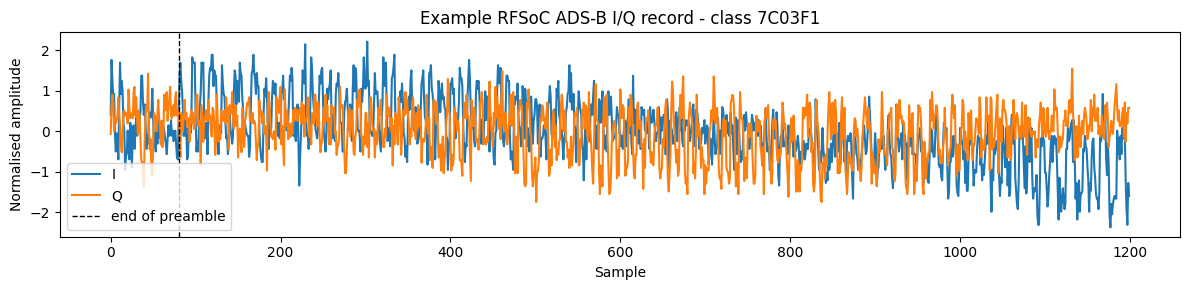

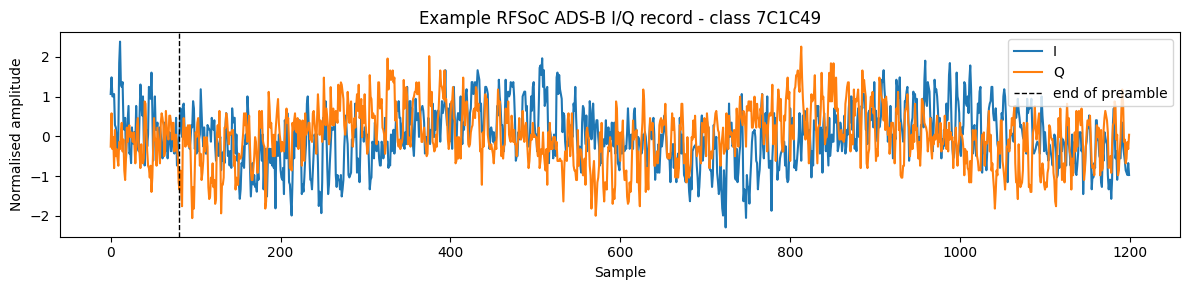

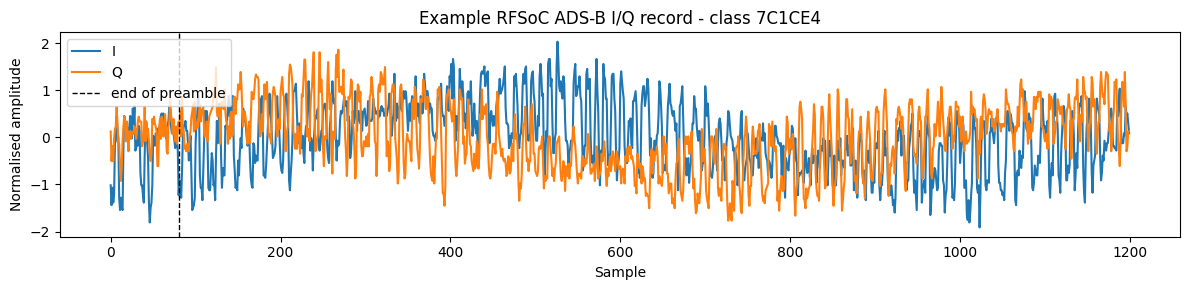

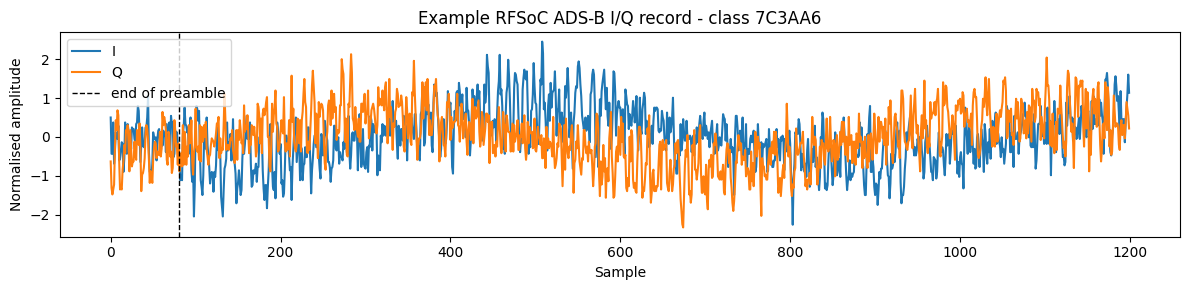

In [ ]:
# Quick sanity plots
# I am plotting only a few examples so the notebook stays readable.

def plot_examples(X, y, class_names, max_classes=4):
    chosen = []
    for class_idx in range(min(len(class_names), max_classes)):
        indices = np.where(y == class_idx)[0]
        if len(indices):
            chosen.append(indices[0])

    for idx in chosen:
        plt.figure(figsize=(12, 3))
        plt.plot(X[idx, 0], label="I")
        plt.plot(X[idx, 1], label="Q")
        plt.axvline(
            CONFIG["preamble_half_symbols"] * CONFIG["samples_per_half_symbol"],
            color="black",
            linestyle="--",
            linewidth=1,
            label="end of preamble",
        )
        plt.title(f"Example RFSoC ADS-B I/Q record - class {class_names[y[idx]]}")
        plt.xlabel("Sample")
        plt.ylabel("Normalised amplitude")
        plt.legend()
        plt.tight_layout()
        plt.show()


plot_examples(X, y, class_names)


## Model

For this baseline I am using the same compact 1D CNN on raw I/Q samples as the CSV experiment. The model sees only the two normalised I/Q channels. The decoded message, ICAO address, DF, type code, and timestamp stay in the table for labels and sanity checks but are not model inputs.

This capture is very small, and several aircraft only appear a handful of times. The immediate goal is to keep the real RFSoC data path connected to the earlier ML workflow and expose the current class coverage. Any validation result here should be treated as a pipeline check rather than evidence of reliable transmitter identification.


In [ ]:
# PyTorch dataset and model

class IQRecordDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


class ADSBIQCNN(nn.Module):
    def __init__(self, num_classes: int, window_len: int):
        super().__init__()
        k = CONFIG["kernel_size"]
        pad = k // 2

        self.features = nn.Sequential(
            nn.Conv1d(2, CONFIG["num_filters_1"], kernel_size=k, padding=pad),
            nn.BatchNorm1d(CONFIG["num_filters_1"]),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(CONFIG["dropout_conv"]),

            nn.Conv1d(CONFIG["num_filters_1"], CONFIG["num_filters_2"], kernel_size=k, padding=pad),
            nn.BatchNorm1d(CONFIG["num_filters_2"]),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(CONFIG["dropout_conv"]),

            nn.Conv1d(CONFIG["num_filters_2"], CONFIG["num_filters_3"], kernel_size=k, padding=pad),
            nn.BatchNorm1d(CONFIG["num_filters_3"]),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(CONFIG["num_filters_3"], CONFIG["fc_units"]),
            nn.ReLU(),
            nn.Dropout(CONFIG["dropout_fc"]),
            nn.Linear(CONFIG["fc_units"], num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


model_preview = ADSBIQCNN(num_classes=len(class_names), window_len=CONFIG["window_len"])
print(model_preview)


ADSBIQCNN(
  (features): Sequential(
    (0): Conv1d(2, 32, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.15, inplace=False)
    (5): Conv1d(32, 64, kernel_size=(7,), stride=(1,), padding=(3,))
    (6): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout(p=0.15, inplace=False)
    (10): Conv1d(64, 96, kernel_size=(7,), stride=(1,), padding=(3,))
    (11): BatchNorm1d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): AdaptiveAvgPool1d(output_size=1)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=96, out_features=128, bias=True)
    (2): ReLU

In [ ]:
# Training and evaluation helpers

def make_loaders(train_idx, val_idx):
    train_ds = IQRecordDataset(X[train_idx], y[train_idx])
    val_ds = IQRecordDataset(X[val_idx], y[val_idx])

    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=0)
    val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=0)
    return train_loader, val_loader


def train_one_epoch(model, loader, criterion, optimiser):
    model.train()
    total_loss = 0.0

    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)

        optimiser.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimiser.step()

        total_loss += loss.item() * len(yb)

    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    preds = []
    targets = []

    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)

        logits = model(xb)
        loss = criterion(logits, yb)

        total_loss += loss.item() * len(yb)
        preds.append(torch.argmax(logits, dim=1).cpu().numpy())
        targets.append(yb.cpu().numpy())

    preds = np.concatenate(preds)
    targets = np.concatenate(targets)

    return {
        "loss": total_loss / len(loader.dataset),
        "accuracy": accuracy_score(targets, preds),
        "macro_f1": f1_score(targets, preds, average="macro", zero_division=0),
        "preds": preds,
        "targets": targets,
    }


In [ ]:
# Stratified K-fold cross-validation
# This is record-level validation. The current capture does not have enough
# independent sessions or aircraft passes for a stronger grouped split.

class_counts = Counter(y)
min_class_count = min(class_counts.values())
n_splits = min(CONFIG["n_splits"], min_class_count)

sufficient_validation_data = len(class_names) >= 2 and n_splits >= 2

fold_results = []
all_fold_preds = []
all_fold_targets = []

if not sufficient_validation_data:
    print(
        "Not enough class coverage for K-fold validation in the current capture. "
        "The decoding and I/Q preparation cells are still useful for checking the data path. "
        "Collect more records per aircraft before treating the training section as an experiment."
    )
else:
    skf = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=CONFIG["random_seed"],
    )

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):
        print(f"\n===== Fold {fold}/{n_splits} =====")
        set_seed(CONFIG["random_seed"] + fold)

        train_loader, val_loader = make_loaders(train_idx, val_idx)
        model = ADSBIQCNN(num_classes=len(class_names), window_len=CONFIG["window_len"]).to(DEVICE)

        criterion = nn.CrossEntropyLoss()
        optimiser = torch.optim.AdamW(
            model.parameters(),
            lr=CONFIG["learning_rate"],
            weight_decay=CONFIG["weight_decay"],
        )

        best_state = None
        best_val_loss = float("inf")
        epochs_without_improvement = 0

        for epoch in range(1, CONFIG["epochs"] + 1):
            train_loss = train_one_epoch(model, train_loader, criterion, optimiser)
            val_metrics = evaluate(model, val_loader, criterion)

            print(
                f"Epoch {epoch:02d} | "
                f"train loss {train_loss:.4f} | "
                f"val loss {val_metrics['loss']:.4f} | "
                f"val acc {val_metrics['accuracy']:.4f} | "
                f"val macro-F1 {val_metrics['macro_f1']:.4f}"
            )

            if val_metrics["loss"] < best_val_loss:
                best_val_loss = val_metrics["loss"]
                best_state = {key: value.cpu().clone() for key, value in model.state_dict().items()}
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1

            if epochs_without_improvement >= CONFIG["patience"]:
                print("Stopping early for this fold.")
                break

        if best_state is not None:
            model.load_state_dict(best_state)

        final_metrics = evaluate(model, val_loader, criterion)

        fold_results.append({
            "fold": fold,
            "val_loss": final_metrics["loss"],
            "val_accuracy": final_metrics["accuracy"],
            "val_macro_f1": final_metrics["macro_f1"],
            "n_train": len(train_idx),
            "n_val": len(val_idx),
        })

        all_fold_preds.append(final_metrics["preds"])
        all_fold_targets.append(final_metrics["targets"])

results_df = pd.DataFrame(fold_results)
display(results_df)



===== Fold 1/5 =====


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Epoch 01 | train loss 2.6217 | val loss 2.6276 | val acc 0.1765 | val macro-F1 0.0426


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Epoch 02 | train loss 2.5077 | val loss 2.5904 | val acc 0.1373 | val macro-F1 0.0458


...

Epoch 14 | train loss 1.6950 | val loss 1.8325 | val acc 0.3600 | val macro-F1 0.2384


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Epoch 15 | train loss 1.6693 | val loss 1.7955 | val acc 0.3600 | val macro-F1 0.2278


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,fold,val_loss,val_accuracy,val_macro_f1,n_train,n_val
0,1,1.767777,0.411765,0.256550,200,51
1,2,2.006316,0.240000,0.148780,201,50
2,3,1.904184,0.380000,0.241322,201,50
3,4,1.925814,0.300000,0.213955,201,50
4,5,1.795487,0.360000,0.227780,201,50


,fold,val_loss,val_accuracy,val_macro_f1,n_train,n_val
count,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
mean,3.000000,1.879916,0.338353,0.217677,200.800000,50.200000
std,1.581139,0.097949,0.068441,0.041632,0.447214,0.447214
min,1.000000,1.767777,0.240000,0.148780,200.000000,50.000000
25%,2.000000,1.795487,0.300000,0.213955,201.000000,50.000000
50%,3.000000,1.904184,0.360000,0.227780,201.000000,50.000000
75%,4.000000,1.925814,0.380000,0.241322,201.000000,50.000000
max,5.000000,2.006316,0.411765,0.256550,201.000000,51.000000



Overall classification report:
              precision    recall  f1-score   support

      7C03F1       1.00      0.06      0.11        17
      7C1C49       0.19      0.12      0.14        26
      7C1CE4       0.18      0.26      0.21        27
      7C3AA6       0.00      0.00      0.00        18
      7C4758       0.91      0.34      0.50        29
      7C4A55       0.47      0.74      0.57        19
      7C6B0B       0.80      1.00      0.89        12
      7C6B40       0.00      0.00      0.00         6
      7C6DDD       0.54      0.35      0.42        20
      7C6DE3       0.00      0.00      0.00        12
      7C7770       0.33      0.21      0.26        28
      7C77F6       0.24      1.00      0.39        25
      7C78AC       0.00      0.00      0.00         5
      7C7A3D       0.00      0.00      0.00         7

    accuracy                           0.34       251
   macro avg       0.33      0.29      0.25       251
weighted avg       0.39      0.34      0.29     

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


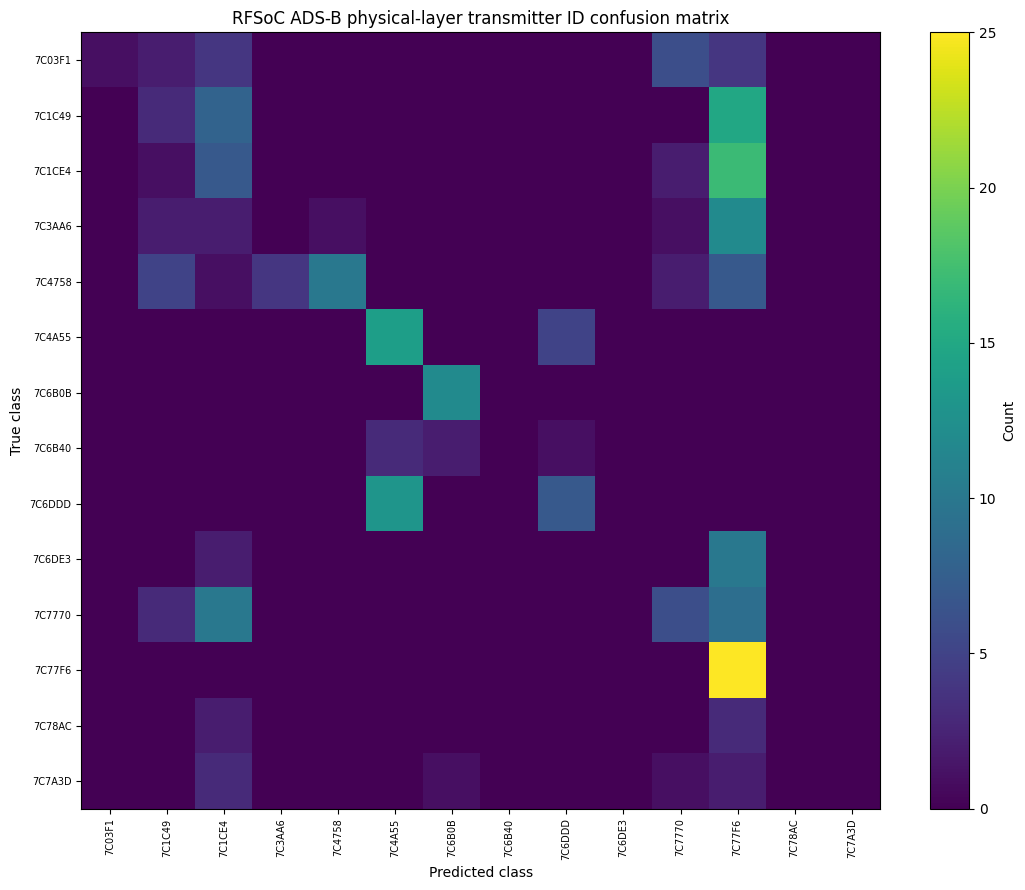

Saved artefacts to: /content/adsb_iq_rfsoc_outputs


In [ ]:
# Summarise results

if results_df.empty:
    print("No training results to summarise yet. Collect at least two usable classes and rerun from the data cells.")
else:
    display(results_df.describe())

    all_preds = np.concatenate(all_fold_preds)
    all_targets = np.concatenate(all_fold_targets)

    print("\nOverall classification report:")
    print(classification_report(all_targets, all_preds, target_names=class_names, zero_division=0))

    cm = confusion_matrix(all_targets, all_preds)

    plt.figure(figsize=(11, 9))
    plt.imshow(cm, aspect="auto")
    plt.title("RFSoC ADS-B physical-layer transmitter ID confusion matrix")
    plt.xlabel("Predicted class")
    plt.ylabel("True class")
    plt.xticks(np.arange(len(class_names)), class_names, rotation=90, fontsize=7)
    plt.yticks(np.arange(len(class_names)), class_names, fontsize=7)
    plt.colorbar(label="Count")
    plt.tight_layout()
    plt.show()

    results_df.to_csv(CONFIG["artifact_dir"] / "kfold_results.csv", index=False)

    with open(CONFIG["artifact_dir"] / "label_mapping.json", "w") as stream:
        json.dump({int(i): name for i, name in enumerate(class_names)}, stream, indent=2)

    print("Saved artefacts to:", CONFIG["artifact_dir"].resolve())


## Notes for next steps

This is still a baseline experiment, not a reliable transmitter-identification result. The useful outcome from this capture is that the complete RFSoC-to-ML data path is now in one place.

Things I would check next:

1. collect substantially more records for each aircraft, including repeated passes and different days;
2. save an explicit capture/session identifier so later validation can group by session instead of mixing one short collection across folds;
3. keep the pyModeS message and aircraft-state fields out of the model inputs, using them only for labels and checks;
4. compare results with and without low-confidence or low-SNR records once those measurements are stored alongside the I/Q;
5. check whether repeated ADS-B payloads or tightly spaced records are making record-level validation look better than it should;
6. add an unknown-class rejection step before treating this as a practical transmitter classifier;
7. once there is enough real data, revisit shorter windows, quantisation-aware training, and a smaller model for the ZCU111/RFSoC direction.
